# Titanic Survival Prediction Model

Comprehensive ML pipeline to predict Titanic passenger survival using EDA, feature engineering, and multiple classification models.

## Section 0 — Imports & Data Loading

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import xgboost as xgb
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [28]:
# Load data
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain columns:\n{train.dtypes}")
print(f"\nTrain head:\n{train.head()}")

Train shape: (891, 12)
Test shape: (418, 11)

Train columns:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Train head:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen,

In [29]:
# Extract target and prepare for unified feature engineering
target = train['Survived']
train_len = len(train)

# Combine train and test for unified feature engineering (prevents train/test skew)
all_data = pd.concat([train.drop('Survived', axis=1), test], ignore_index=True)
print(f"Combined data shape: {all_data.shape}")
print(f"\nMissing values:\n{all_data.isnull().sum()}")

Combined data shape: (1309, 11)

Missing values:
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


## Section 1 — EDA

In [30]:
# Survival rate
survival_rate = target.mean()
print(f"Survival rate: {survival_rate:.2%}")
print(f"Positive class: {target.sum()}/{len(target)}")
print(f"Negative class: {(1-target).sum()}/{len(target)}")

Survival rate: 38.38%
Positive class: 342/891
Negative class: 549/891


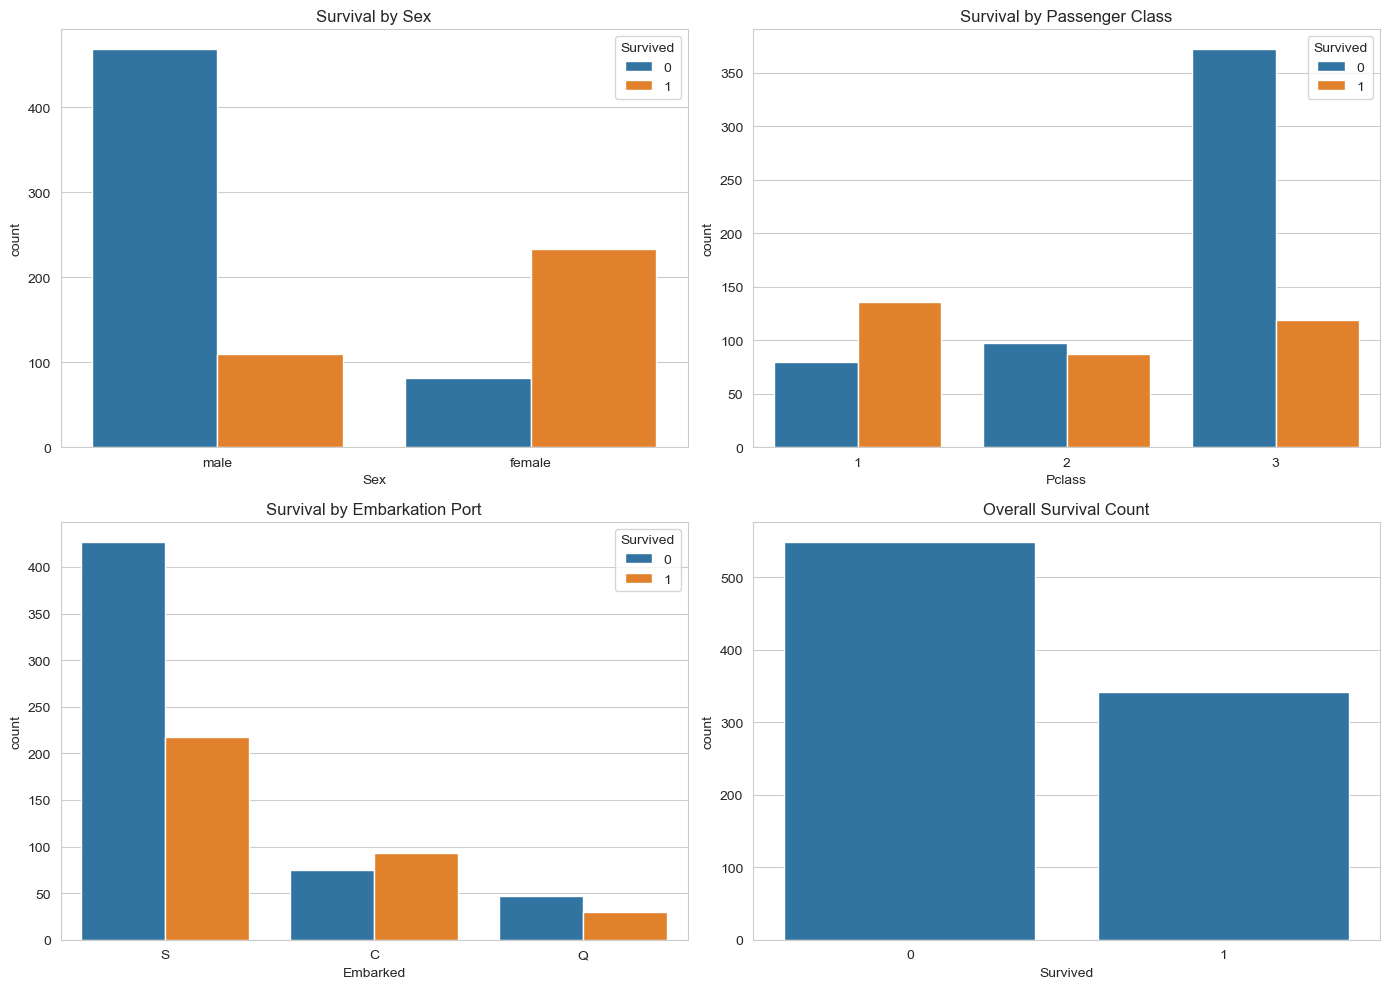

In [31]:
# Countplots for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sex
sns.countplot(data=train, x='Sex', hue='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival by Sex')

# Pclass
sns.countplot(data=train, x='Pclass', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Passenger Class')

# Embarked
sns.countplot(data=train, x='Embarked', hue='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival by Embarkation Port')

# Overall Survived
sns.countplot(data=train, x='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Overall Survival Count')

plt.tight_layout()
plt.show()

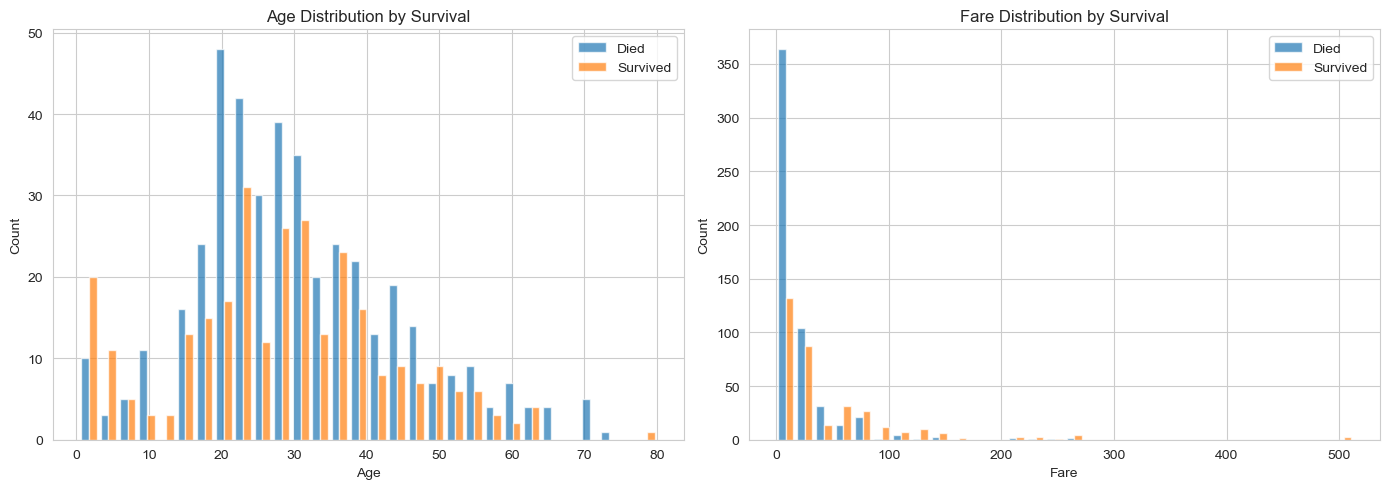

In [32]:
# Histplots for numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
axes[0].hist([train[train['Survived']==0]['Age'].dropna(),
              train[train['Survived']==1]['Age'].dropna()],
             label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Survival')
axes[0].legend()

# Fare
axes[1].hist([train[train['Survived']==0]['Fare'].dropna(),
              train[train['Survived']==1]['Fare'].dropna()],
             label=['Died', 'Survived'], bins=30, alpha=0.7)
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')
axes[1].set_title('Fare Distribution by Survival')
axes[1].legend()

plt.tight_layout()
plt.show()

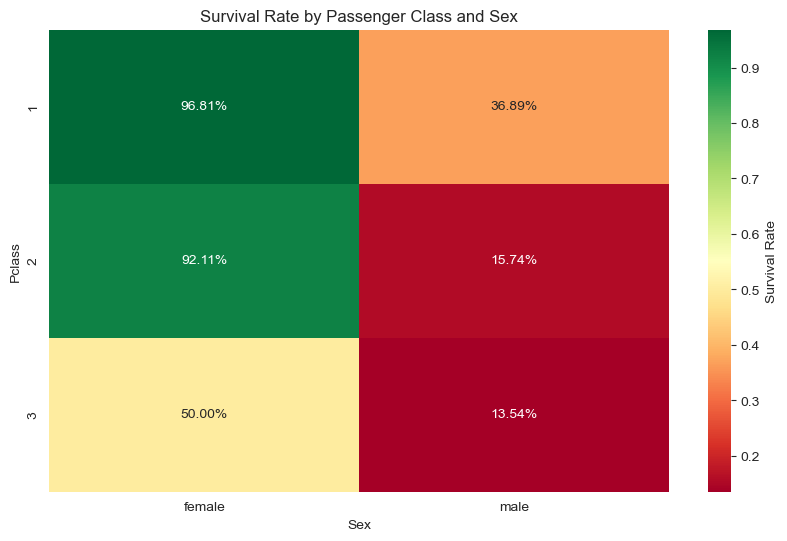

In [33]:
# Heatmap: survival rate by Pclass × Sex
survival_by_pclass_sex = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
sns.heatmap(survival_by_pclass_sex, annot=True, fmt='.2%', cmap='RdYlGn', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate by Passenger Class and Sex')
plt.show()

In [34]:
# Missing value summary on combined data
missing_summary = all_data.isnull().sum()
missing_pct = (missing_summary / len(all_data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

          Missing Count  Percentage
Cabin              1014       77.46
Age                 263       20.09
Embarked              2        0.15
Fare                  1        0.08


## Section 2 — Feature Engineering (on all_data)

In [35]:
# Create a copy for feature engineering
df = all_data.copy()

# Extract Title from Name
def extract_title(name):
    title_match = re.search(r' ([A-Za-z]+)\.', name)
    return title_match.group(1) if title_match else 'Unknown'

df['Title'] = df['Name'].apply(extract_title)
print(f"Unique titles: {df['Title'].unique()}")
print(f"\nTitle counts:\n{df['Title'].value_counts()}")

Unique titles: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer' 'Dona']

Title counts:
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Mlle          2
Major         2
Ms            2
Lady          1
Sir           1
Mme           1
Don           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64


In [36]:
# Consolidate rare titles
title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')

print(f"Consolidated title counts:\n{df['Title'].value_counts()}")

Consolidated title counts:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64


In [37]:
# Impute Age by Title + Pclass median
age_by_title_pclass = df.groupby(['Title', 'Pclass'])['Age'].median()
print(f"Age medians by Title and Pclass:\n{age_by_title_pclass}")

for title in df['Title'].unique():
    for pclass in df['Pclass'].unique():
        mask = (df['Title'] == title) & (df['Pclass'] == pclass) & (df['Age'].isnull())
        median_age = age_by_title_pclass.get((title, pclass), df['Age'].median())
        df.loc[mask, 'Age'] = median_age

# Fill remaining NaN with overall median
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f"\nMissing Age after imputation: {df['Age'].isnull().sum()}")

Age medians by Title and Pclass:
Title   Pclass
Master  1          6.0
        2          2.0
        3          6.0
Miss    1         30.0
        2         20.0
        3         18.0
Mr      1         41.5
        2         30.0
        3         26.0
Mrs     1         45.0
        2         30.5
        3         31.0
Rare    1         47.0
        2         41.0
        3          NaN
Name: Age, dtype: float64

Missing Age after imputation: 0


In [38]:
# Extract Deck from Cabin
df['Deck'] = df['Cabin'].fillna('U').apply(lambda x: x[0])
print(f"Unique decks: {sorted(df['Deck'].unique())}")
print(f"\nDeck counts:\n{df['Deck'].value_counts()}")

Unique decks: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'U']

Deck counts:
Deck
U    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64


In [39]:
# Fill missing Fare with median
df['Fare'].fillna(df['Fare'].median(), inplace=True)
print(f"Missing Fare after imputation: {df['Fare'].isnull().sum()}")

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print(f"Missing Embarked after imputation: {df['Embarked'].isnull().sum()}")

Missing Fare after imputation: 0
Missing Embarked after imputation: 0


In [40]:
# Engineer new features

# FamilySize: total family on ship
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: binary flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# LogFare: log transform (handles Fare=0)
df['LogFare'] = np.log1p(df['Fare'])

# FareBin: quantile-based binning
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Very Low', 'Low', 'Mid', 'High'], duplicates='drop')

# AgeBin: age groups
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

print(f"New features created:")
print(f"FamilySize: {df['FamilySize'].describe()}")
print(f"IsAlone: {df['IsAlone'].value_counts()}")
print(f"\nFareBin: {df['FareBin'].value_counts(dropna=False)}")
print(f"\nAgeBin: {df['AgeBin'].value_counts(dropna=False)}")

New features created:
FamilySize: count    1309.000000
mean        1.883881
std         1.583639
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: FamilySize, dtype: float64
IsAlone: IsAlone
1    790
0    519
Name: count, dtype: int64

FareBin: FareBin
Very Low    337
Mid         328
High        323
Low         321
Name: count, dtype: int64

AgeBin: AgeBin
YoungAdult    701
Adult         327
Teen          146
Child         102
Senior         33
Name: count, dtype: int64


## Section 3 — Preprocessing

In [41]:
# Select final features
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'LogFare',
                'FamilySize', 'IsAlone', 'Title', 'Deck', 'FareBin', 'AgeBin', 'Embarked']

# Drop unnecessary columns
df = df[feature_cols].copy()
print(f"Final features shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Final features shape: (1309, 14)

Data types:
Pclass           int64
Sex             object
Age            float64
SibSp            int64
Parch            int64
Fare           float64
LogFare        float64
FamilySize       int64
IsAlone          int64
Title           object
Deck            object
FareBin       category
AgeBin        category
Embarked        object
dtype: object

Missing values:
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
LogFare       0
FamilySize    0
IsAlone       0
Title         0
Deck          0
FareBin       0
AgeBin        0
Embarked      0
dtype: int64


In [42]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Sex', 'Title', 'Deck', 'FareBin', 'AgeBin', 'Embarked'],
                            drop_first=False)

print(f"Encoded features shape: {df_encoded.shape}")
print(f"\nFirst few rows:\n{df_encoded.head()}")

Encoded features shape: (1309, 36)

First few rows:
   Pclass   Age  SibSp  Parch     Fare   LogFare  FamilySize  IsAlone  \
0       3  22.0      1      0   7.2500  2.110213           2        0   
1       1  38.0      1      0  71.2833  4.280593           2        0   
2       3  26.0      0      0   7.9250  2.188856           1        1   
3       1  35.0      1      0  53.1000  3.990834           2        0   
4       3  35.0      0      0   8.0500  2.202765           1        1   

   Sex_female  Sex_male  ...  FareBin_Mid  FareBin_High  AgeBin_Child  \
0       False      True  ...        False         False         False   
1        True     False  ...        False          True         False   
2        True     False  ...        False         False         False   
3        True     False  ...        False          True         False   
4       False      True  ...        False         False         False   

   AgeBin_Teen  AgeBin_YoungAdult  AgeBin_Adult  AgeBin_Senior  Embark

In [43]:
# Re-split into train and test
X_train = df_encoded[:train_len].copy()
X_test = df_encoded[train_len:].copy()
y_train = target.copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (891, 36)
X_test shape: (418, 36)
y_train shape: (891,)


In [44]:
# Align X_test columns to X_train (handles unseen categories)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"After alignment:")
print(f"X_train columns: {X_train.shape[1]}")
print(f"X_test columns: {X_test.shape[1]}")
print(f"Column mismatch: {set(X_train.columns) - set(X_test.columns)}")

After alignment:
X_train columns: 36
X_test columns: 36
Column mismatch: set()


## Section 4 — Model Training & Comparison

In [45]:
# Initialize models
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6,
                                           min_samples_leaf=2, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                   max_depth=4, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=4, random_state=42, use_label_encoder=False,
                                eval_metric='logloss')
}

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:25} | Mean: {scores.mean():.4f} ± {scores.std():.4f} | Scores: {scores}")

Logistic Regression       | Mean: 0.8283 ± 0.0191 | Scores: [0.84357542 0.83707865 0.79775281 0.81460674 0.84831461]
Random Forest             | Mean: 0.8372 ± 0.0082 | Scores: [0.84916201 0.83707865 0.83146067 0.8258427  0.84269663]
Gradient Boosting         | Mean: 0.8406 ± 0.0223 | Scores: [0.87709497 0.84831461 0.80898876 0.83146067 0.83707865]
XGBoost                   | Mean: 0.8339 ± 0.0185 | Scores: [0.8603352  0.84831461 0.80898876 0.83146067 0.82022472]


In [46]:
# Store results for later use
best_model_name = max(cv_results, key=lambda x: cv_results[x].mean())
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name}")


Best model: Gradient Boosting


## Section 5 — Evaluation

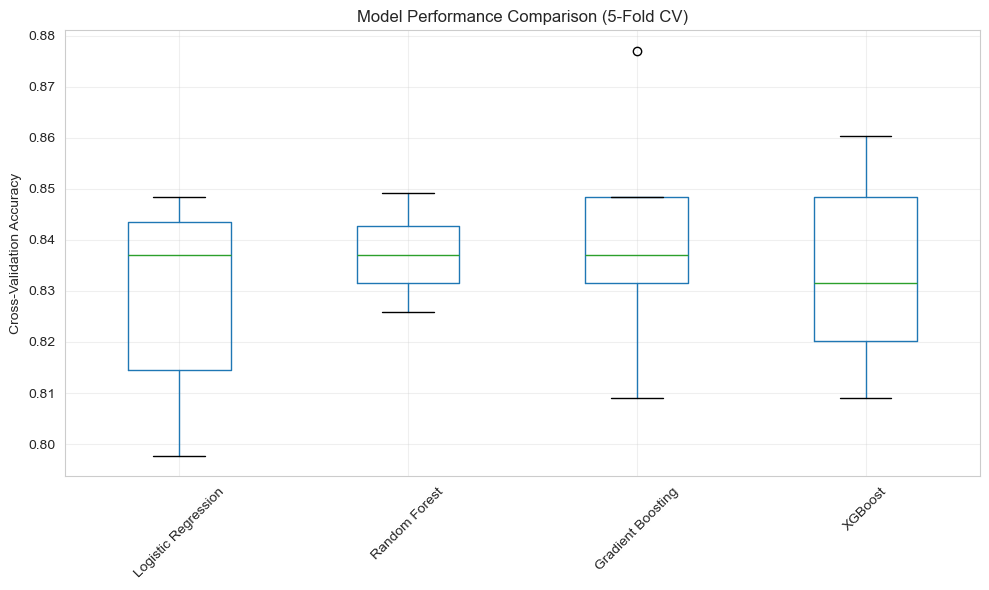

In [47]:
# Boxplot comparing CV accuracy across models
results_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(10, 6))
results_df.boxplot(ax=ax)
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Model Performance Comparison (5-Fold CV)')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# Fit best model on full training data
best_model.fit(X_train, y_train)
y_pred_train = best_model.predict(X_train)

print(f"Best model: {best_model_name}")
print(f"Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")

Best model: Gradient Boosting
Training accuracy: 0.9405


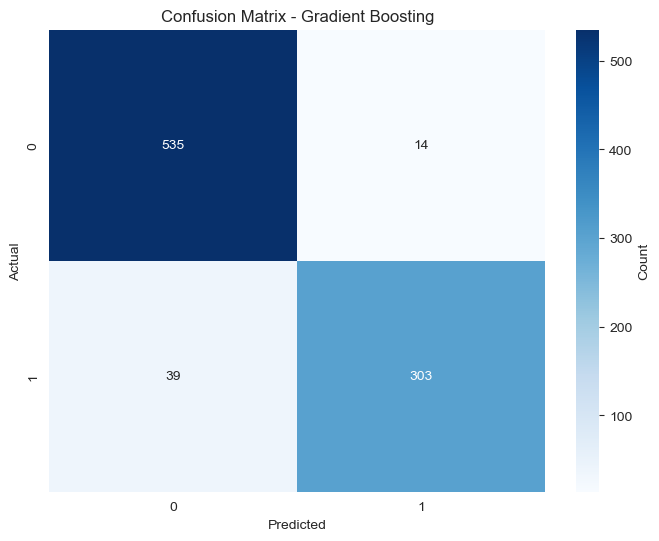

In [49]:
# Confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [50]:
# Classification report
print(classification_report(y_train, y_pred_train, target_names=['Died', 'Survived']))

              precision    recall  f1-score   support

        Died       0.93      0.97      0.95       549
    Survived       0.96      0.89      0.92       342

    accuracy                           0.94       891
   macro avg       0.94      0.93      0.94       891
weighted avg       0.94      0.94      0.94       891



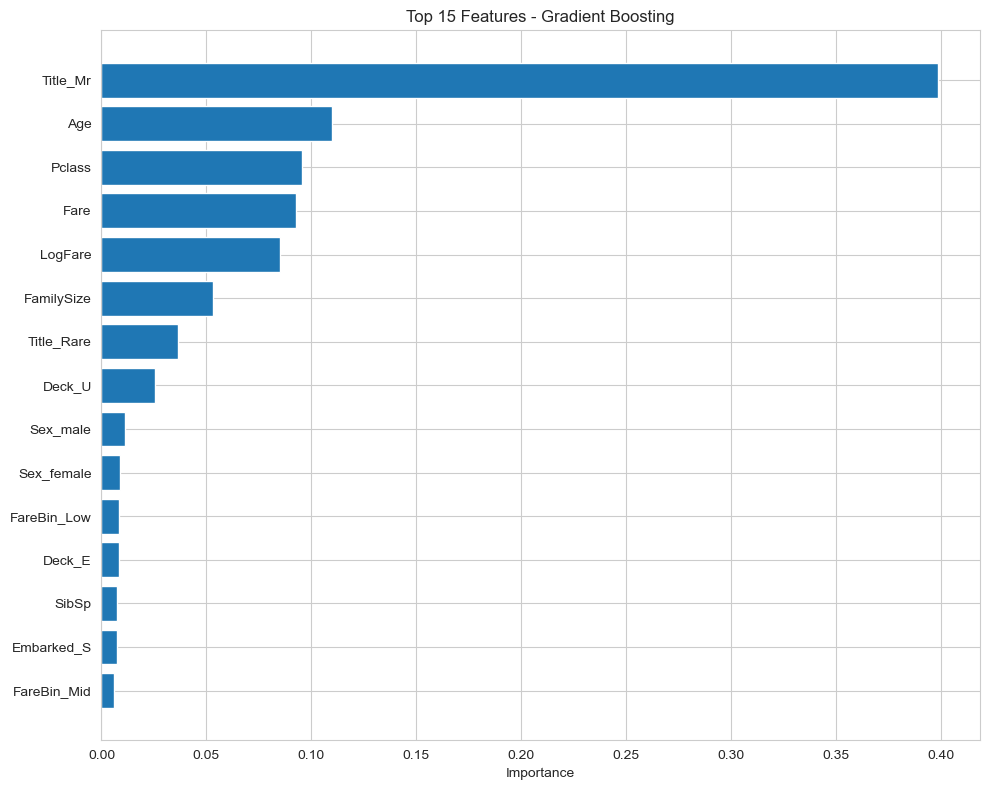


Top 15 Features:
        Feature  Importance
12     Title_Mr    0.398642
1           Age    0.109968
0        Pclass    0.095702
4          Fare    0.092588
5       LogFare    0.085271
6    FamilySize    0.053033
14   Title_Rare    0.036626
23       Deck_U    0.025282
9      Sex_male    0.011219
8    Sex_female    0.008605
25  FareBin_Low    0.008514
19       Deck_E    0.008405
2         SibSp    0.007533
35   Embarked_S    0.007445
26  FareBin_Mid    0.005787


In [51]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    # Plot top 15 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = importance_df.head(15)
    ax.barh(range(len(top_15)), top_15['Importance'])
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 15 Features - {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f"\nTop 15 Features:\n{top_15}")
elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps['model'], 'coef_'):
    # For Logistic Regression via Pipeline
    coef = best_model.named_steps['model'].coef_[0]
    feature_names = X_train.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    }).sort_values('Coefficient', ascending=False, key=abs)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = importance_df.head(15)
    colors = ['green' if x > 0 else 'red' for x in top_15['Coefficient']]
    ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['Feature'])
    ax.set_xlabel('Coefficient')
    ax.set_title(f'Top 15 Features - {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(f"\nTop 15 Features:\n{top_15}")

## Section 6 — Final Prediction & Submission

In [52]:
# Make predictions on test set
y_pred_test = best_model.predict(X_test)

print(f"Predictions shape: {y_pred_test.shape}")
print(f"Unique predictions: {np.unique(y_pred_test)}")
print(f"Survival rate in predictions: {y_pred_test.mean():.2%}")

Predictions shape: (418,)
Unique predictions: [0 1]
Survival rate in predictions: 36.60%


In [53]:
# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred_test.astype(int)
})

print(f"Submission shape: {submission.shape}")
print(f"\nFirst 10 rows:\n{submission.head(10)}")
print(f"\nLast 10 rows:\n{submission.tail(10)}")

Submission shape: (418, 2)

First 10 rows:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Last 10 rows:
     PassengerId  Survived
408         1300         1
409         1301         1
410         1302         1
411         1303         1
412         1304         0
413         1305         0
414         1306         1
415         1307         0
416         1308         0
417         1309         1


In [54]:
# Save submission
submission.to_csv('../outputs/submission.csv', index=False)
print(f"Submission saved to ../outputs/submission.csv")

# Verify against schema
gender_submission = pd.read_csv('../data/gender_submission.csv')
print(f"\nGender submission shape: {gender_submission.shape}")
print(f"Our submission shape: {submission.shape}")
print(f"\nSchema match: {list(submission.columns) == list(gender_submission.columns)}")
print(f"All predictions are 0 or 1: {set(submission['Survived']).issubset({0, 1})}")

Submission saved to ../outputs/submission.csv

Gender submission shape: (418, 2)
Our submission shape: (418, 2)

Schema match: True
All predictions are 0 or 1: True
